# GraphRAG Benchmark (HotpotQA)

Grounded in the standard multi-hop QA paper benchmark:

> **HotpotQA** — Yang et al., EMNLP 2018  
> Distractor setting: 2 gold Wikipedia paragraphs + 8 distractors per question.

Used throughout GraphRAG literature (systematic RAG vs GraphRAG evals, multi-hop GraphRAG papers).

| Method | Role |
|--------|------|
| Semantic (vector) | Baseline vector RAG |
| GraphRAG global | Thematic / corpus-wide (community reports) |
| GraphRAG local | Entity + relationship retrieval |
| **Hybrid (vec + graph local)** | Retrieve chunks + graph local → **one** fusion call |
| Fast/basic (Lazy-style) | Cheap GraphRAG 3.x fast index + basic search |
| DRIFT (optional) | MS GraphRAG native hybrid (slow on tiny local LLMs) |

**Why hybrid looked weak before:** it called `semantic.query()` (full LLM answer), threw that answer away, then fused chunks with a graph prose answer via a *third* LLM call — wasting tokens and diluting facts. Fixed: `retrieve()` only + one fusion.

In [1]:
# ── Config ─────────────────────────────────────────────────
BENCHMARK = "hotpotqa"   # "hotpotqa" (paper) | "wikipedia" (custom)
N_HOTPOT = 12
FETCH_OR_BUILD = True
RUN_BENCHMARK = False    # results already in results/; set True to re-run
REUSE_INDEXES = True
METHODS = [
    "semantic_rag",
    "graph_rag",         # global
    "graph_local_rag",   # local
    "hybrid_rag",        # vec retrieve + graph local fusion
    "lazygraph_rag",     # fast/basic
]
# ───────────────────────────────────────────────────────────

import sys
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))
load_dotenv(PROJECT_ROOT / ".env")

from rag_benchmark import (
    BenchmarkConfig, BenchmarkRunner, create_tracked_client,
    fetch_corpus, build_hotpot_subset,
)
from rag_benchmark.charts import METHOD_LABELS, render_notebook_dashboard
from rag_benchmark.hybrid_rag import HybridRAG

# Guardrail: hybrid must not double-generate
src = (PROJECT_ROOT / "src/rag_benchmark/hybrid_rag.py").read_text()
assert "self.semantic.retrieve(" in src and "self.semantic.query(" not in src
print("Hybrid guardrail OK: retrieve-only + one fusion call")

config = BenchmarkConfig.from_yaml(PROJECT_ROOT)
config.project_root = PROJECT_ROOT
config.reuse_indexes = REUSE_INDEXES
print(f"Backend={config.llm_backend} chat={config.chat_model} embed={config.embedding_model}")

Hybrid guardrail OK: retrieve-only + one fusion call
Backend=local chat=llama3.2:3b embed=all-MiniLM-L6-v2


## 1. Build eval corpus

**HotpotQA distractor** builds a *closed* paragraph set from the paper JSON (no full-Wikipedia crawl/index).

In [2]:
if BENCHMARK == "hotpotqa":
    if FETCH_OR_BUILD:
        paths = build_hotpot_subset(
            project_root=PROJECT_ROOT, n_questions=N_HOTPOT, prefer_hard=True
        )
        print(paths["meta"])
    config.corpus_dir = PROJECT_ROOT / "data" / "corpus_hotpot"
    config.qa_path = PROJECT_ROOT / "data" / "qa" / "hotpot_eval.json"
    # Separate Chroma collection + GraphRAG workspace so we don't mix wiki indexes
    config.semantic_collection = "hotpot_semantic"
    config.graph_workspace = PROJECT_ROOT / "graphrag_workspaces" / "hotpot"
    config.lazy_workspace = PROJECT_ROOT / "graphrag_workspaces" / "hotpot_lazy"
    config.max_documents = 10_000  # use all Hotpot paragraphs written for the subset
else:
    config.corpus_dir = PROJECT_ROOT / "data" / "corpus"
    config.qa_path = PROJECT_ROOT / "data" / "qa" / "eval_questions.json"
    if FETCH_OR_BUILD:
        titles = [
            "Albert Einstein", "Python (programming language)", "Machine learning",
            "Artificial intelligence", "Solar System", "Mars", "Jupiter",
            "World War II", "Neural network", "United States",
        ]
        fetch_corpus(titles, config.corpus_dir, max_chars=10_000)

n_docs = len(list(config.corpus_dir.glob("*.txt")))
print(f"Corpus: {config.corpus_dir} ({n_docs} docs)")
print(f"QA:     {config.qa_path}")

{'dataset': 'HotpotQA', 'paper': 'Yang et al., EMNLP 2018', 'citation': 'https://hotpotqa.github.io/', 'setting': 'distractor', 'source': 'hotpotqa/hotpot_qa (HuggingFace)', 'n_questions': 12, 'n_documents': 119, 'type_counts': {'bridge': 6, 'comparison': 6}, 'corpus_dir': '/Users/jimmyscray/Code/rag-benchmark/data/corpus_hotpot', 'qa_path': '/Users/jimmyscray/Code/rag-benchmark/data/qa/hotpot_eval.json'}
Corpus: /Users/jimmyscray/Code/rag-benchmark/data/corpus_hotpot (119 docs)
QA:     /Users/jimmyscray/Code/rag-benchmark/data/qa/hotpot_eval.json


## 2. Run methods

GraphRAG uses **fast** indexing locally (spaCy NLP graph) — `standard` LLM extraction often fails on 3B models during community reports.

In [3]:
results_dir = config.results_dir()

if RUN_BENCHMARK:
    runner = BenchmarkRunner(config, create_tracked_client(config))
    print(f"{len(runner.questions)} questions")
    for q in runner.questions[:5]:
        print(f"  [{q.query_type}] {q.question[:80]}")
    results = runner.run_all(methods=METHODS)
    saved = runner.save_results(results)
else:
    saved = {
        "summary_df": pd.read_csv(results_dir / "summary.csv"),
        "accuracy_df": pd.read_csv(results_dir / "accuracy_results.csv"),
        "latency_df": pd.read_csv(results_dir / "latency_results.csv"),
        "token_df": pd.read_csv(results_dir / "token_results.csv"),
        "scenario_df": pd.read_csv(results_dir / "scenario_results.csv")
        if (results_dir / "scenario_results.csv").exists() else pd.DataFrame(),
    }
    results = None
    print("Loaded saved results")

Loaded saved results


## 3. Charts + leaderboard (quality, tokens, scenarios)

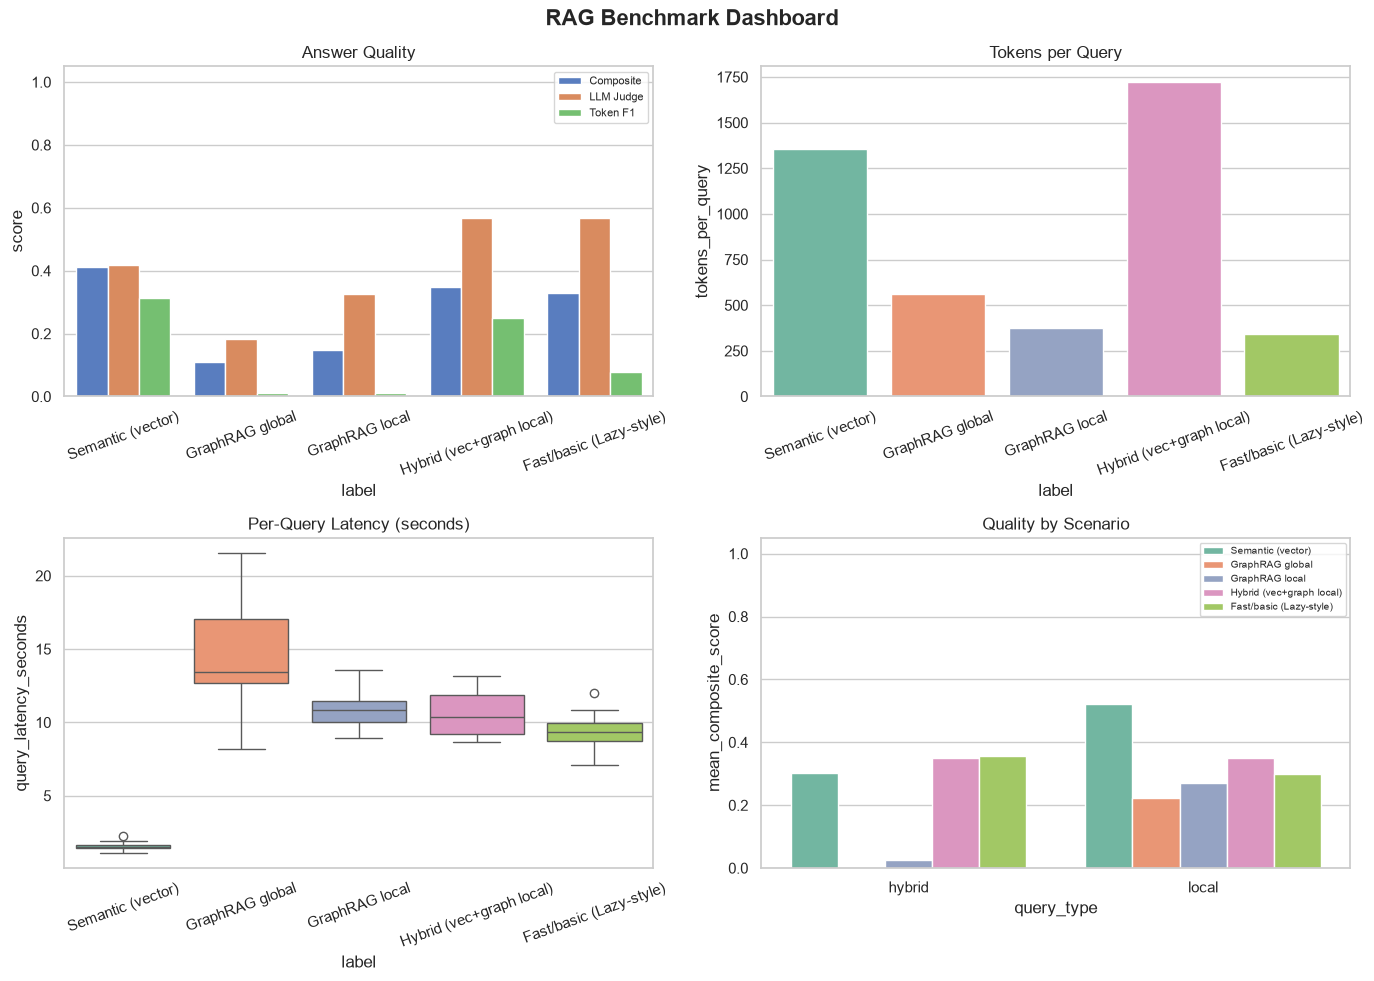

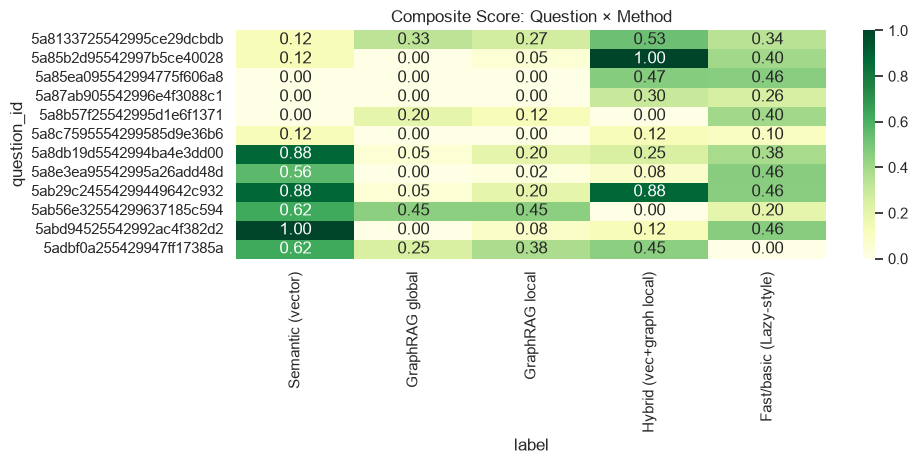

,label,mean_composite_score,mean_llm_judge,mean_token_f1,exact_match_rate,total_tokens,tokens_per_query,mean_query_latency_seconds
0,Semantic (vector),0.411,0.417,0.312,0.417,16242,1353.500,1.554
3,Hybrid (vec+graph local),0.350,0.567,0.248,0.167,20667,1722.250,10.717
4,Fast/basic (Lazy-style),0.328,0.567,0.077,0.000,4133,344.417,9.312
2,GraphRAG local,0.147,0.327,0.012,0.000,4497,374.750,10.885
1,GraphRAG global,0.111,0.183,0.010,0.000,6725,560.417,14.815


In [4]:
frames = render_notebook_dashboard(saved=saved, results_dir=results_dir)
summary = frames["summary"]
cols = [c for c in [
    "label", "mean_composite_score", "mean_llm_judge", "mean_token_f1",
    "exact_match_rate", "total_tokens", "tokens_per_query",
    "mean_query_latency_seconds",
] if c in summary.columns]
display(summary.sort_values("mean_composite_score", ascending=False)[cols].round(3))

In [5]:
scenario = frames.get("scenario")
if scenario is not None and not scenario.empty:
    pivot = scenario.pivot_table(
        index="label", columns="query_type", values="mean_composite_score", observed=False
    ).round(3)
    print("Quality by Hotpot-style scenario (bridge→hybrid, comparison→local):")
    display(pivot)

print("\nToken efficiency (quality per 1k tokens):")
eff = summary.copy()
eff["quality_per_1k_tokens"] = (
    eff["mean_composite_score"] / (eff["total_tokens"].clip(lower=1) / 1000)
).round(3)
display(eff[["label", "mean_composite_score", "total_tokens", "quality_per_1k_tokens"]]
        .sort_values("quality_per_1k_tokens", ascending=False))

Quality by Hotpot-style scenario (bridge→hybrid, comparison→local):


query_type,hybrid,local
label,,
Semantic (vector),0.302,0.521
GraphRAG global,0.000,0.221
GraphRAG local,0.025,0.270
Hybrid (vec+graph local),0.349,0.350
Fast/basic (Lazy-style),0.357,0.298



Token efficiency (quality per 1k tokens):


,label,mean_composite_score,total_tokens,quality_per_1k_tokens
4,Fast/basic (Lazy-style),0.327604,4133,0.079
2,GraphRAG local,0.147374,4497,0.033
0,Semantic (vector),0.411458,16242,0.025
3,Hybrid (vec+graph local),0.349596,20667,0.017
1,GraphRAG global,0.110737,6725,0.016


## 4. Sample answers

In [6]:
if results:
    for result in results:
        print(f"\n=== {METHOD_LABELS.get(result.method, result.method)} | tokens={result.ledger.total().total_tokens} ===")
        for row in result.answers[:2]:
            print(f"[{row.get('query_type')}] Q: {row['question']}")
            print(f"A: {row['answer'][:350]}\n")
else:
    print("Set RUN_BENCHMARK=True for live answers.")

Set RUN_BENCHMARK=True for live answers.
